In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score


In [6]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [12]:
X=data[['AveRooms']].values
y=data['Price'].values

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [42]:
w=0
b=0
learning_rate=0.01
epochs=1000
cost_history=[]
n=len(X_train_scaled)
for i in range(epochs):
    y_pred=w*X_train_scaled.flatten()+b
    cost=(1/(2*n))*np.sum((y_pred-y_train)**2)
    cost_history.append(cost)
    dw=(1/n)*np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db=(1/n)*np.sum(y_pred-y_train)
    w=w-learning_rate*dw
    b=b-learning_rate*db
    if i%100==0:
       
        print(f"Epoch {i},cost={cost:4f}")
y_pred_gd=w*X_test_scaled.flatten()+b


Epoch 0,cost=2.814871
Epoch 100,cost=0.941435
Epoch 200,cost=0.690433
Epoch 300,cost=0.656804
Epoch 400,cost=0.652298
Epoch 500,cost=0.651694
Epoch 600,cost=0.651613
Epoch 700,cost=0.651603
Epoch 800,cost=0.651601
Epoch 900,cost=0.651601


In [43]:
print("Gradient Desent")
print("----------")
print("weight:",w)
print("Bias:",b)
print("Mse:",mean_squared_error(y_test,y_pred_gd))
print("R2 score:",r2_score(y_test,y_pred_gd))

Gradient Desent
----------
weight: 0.18323090648660517
Bias: 2.0718574888450205
Mse: 1.292327655590046
R2 score: 0.013798228607320828


In [44]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta=np.linalg.inv(X_train_ne.T@X_train_ne)@X_train_ne.T@y_train
y_pred_ne=X_test_ne@theta

In [45]:
print("\n Normal equation")
print("------------")
print("Intercept",theta[0])
print("slope",theta[1])
print("Mse:",mean_squared_error(y_test,y_pred_ne))
print("R2 score:",r2_score(y_test,y_pred_ne))


 Normal equation
------------
Intercept 1.6547622685968417
slope 0.07675558963126736
Mse: 1.2923314440807299
R2 score: 0.013795337532284901


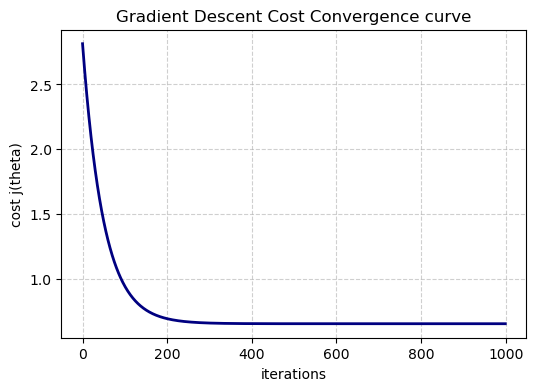

In [56]:
plt.figure(figsize=(6,4))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence curve')
plt.xlabel('iterations')
plt.ylabel('cost j(theta)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

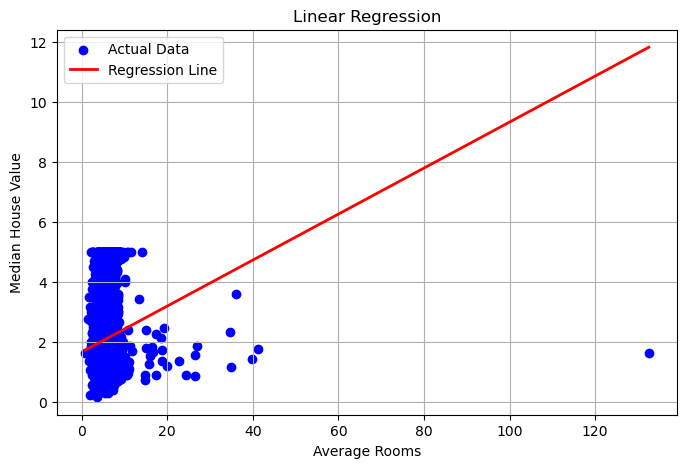

In [60]:
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='blue', label = 'Actual Data')

plt.plot(
X_test.flatten()[index],
y_pred_ne[index],
color='red',
linewidth=2,
label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)

plt.show()